In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tqdm import tqdm

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# ---------------- CONFIG ----------------
HIST_LEN = 36
HORIZON  = 288
RANDOM_SEED = 23
np.random.seed(RANDOM_SEED)

# --- weather time series ---
df_weather = pd.read_csv(
    "../data/clean/valais_clean.csv",
    dtype={"station": str}
)

df_weather["time"] = pd.to_datetime(
    df_weather["time"],
    format="%Y%m%d%H%M"
)

# --- station metadata ---
df_stations = pd.read_csv(
    "../data/clean/valais_stations.csv",
    dtype={"station": str}
)

df = df_weather.merge(
    df_stations[["station", "east", "north", "altitude"]],
    on="station",
    how="left"
)

clf_selected_features = [
    "precip",
    "temperature",
    "East",
    "North",
    "pressure",
    "moisture",
]

clf_metadata_features = [
    "east",
    "north",
    "altitude",
]

# ---- REGRESSOR FEATURES (MUST MATCH TRAINING) ----
reg_selected_features = [
    "precip",
    "temperature",
    "pressure",
    "moisture",
]

reg_metadata_features = [
    "altitude",
]

clf_features = clf_selected_features + clf_metadata_features

df_clf = df[["time", "station"] + clf_features].copy()

clf_pivot = df_clf.pivot(
    index="time",
    columns="station",
    values=clf_features
)

clf_pivot.columns = [
    f"{feat}_{station}" for feat, station in clf_pivot.columns
]

clf_pivot = clf_pivot.sort_index().dropna()

reg_features = reg_selected_features + reg_metadata_features

df_reg = df[["time", "station"] + reg_features].copy()

reg_pivot = df_reg.pivot(
    index="time",
    columns="station",
    values=reg_features
)

reg_pivot.columns = [
    f"{feat}_{station}" for feat, station in reg_pivot.columns
]

reg_pivot = reg_pivot.sort_index().dropna()

def split_and_scale(df_pivot):
    n = len(df_pivot)
    s1 = int(0.6 * n)
    s2 = int(0.8 * n)

    train = df_pivot.iloc[:s1]
    val   = df_pivot.iloc[s1:s2]
    test  = df_pivot.iloc[s2:]

    scaler = StandardScaler()
    scaler.fit(train)

    train_scaled = pd.DataFrame(
        scaler.transform(train),
        columns=train.columns,
        index=train.index
    )

    val_scaled = pd.DataFrame(
        scaler.transform(val),
        columns=val.columns,
        index=val.index
    )

    test_scaled = pd.DataFrame(
        scaler.transform(test),
        columns=test.columns,
        index=test.index
    )

    return train_scaled, val_scaled, test_scaled, scaler

train_clf, val_clf, test_clf, scaler_clf = split_and_scale(clf_pivot)
train_reg, val_reg, test_reg, scaler_reg = split_and_scale(reg_pivot)

precip_cols = [c for c in reg_pivot.columns if c.startswith("precip_")]
stations = [c.split("_", 1)[1] for c in precip_cols]

true_precip = reg_pivot.loc[test_reg.index, precip_cols].values

precip_cols = [f"precip_{s}" for s in stations]
precip_idx = [test_reg.columns.get_loc(c) for c in precip_cols]

precip_mean = scaler_reg.mean_[precip_idx]
precip_std  = scaler_reg.scale_[precip_idx]

precip_col_idx = {
    s: test_reg.columns.get_loc(f"precip_{s}")
    for s in stations
}


In [3]:
from tensorflow.keras.utils import to_categorical

num_stations = len(stations)
station_to_index = {s: i for i, s in enumerate(stations)}

station_onehots = {
    s: to_categorical(station_to_index[s], num_classes=num_stations)
    for s in stations
}

precip_cols = [f"precip_{s}" for s in stations]

precip_col_idx = {
    s: test_reg.columns.get_loc(f"precip_{s}")
    for s in stations
}

precip_idx = [test_reg.columns.get_loc(c) for c in precip_cols]

precip_mean = scaler_reg.mean_[precip_idx]
precip_std  = scaler_reg.scale_[precip_idx]

In [30]:
def roll_and_insert_clf(x_clf, y_phys):
    x_new = x_clf[0, 1:, :].copy()
    last  = x_clf[0, -1, :].copy()

    for j, s in enumerate(stations):
        idx = test_clf.columns.get_loc(f"precip_{s}")
        last[idx] = (y_phys[j] - scaler_clf.mean_[idx]) / scaler_clf.scale_[idx]

    return np.concatenate([x_new, [last]])[np.newaxis, :, :]

def roll_and_insert_reg(x_reg, y_phys):
    x_new = x_reg[0, 1:, :].copy()
    last  = x_reg[0, -1, :].copy()

    for j, s in enumerate(stations):
        idx = precip_col_idx[s]
        last[idx] = (y_phys[j] - precip_mean[j]) / precip_std[j]

    return np.concatenate([x_new, [last]])[np.newaxis, :, :]


In [32]:
def recursive_forecast(
    classifier,
    regressor,
    x_class_init,
    x_reg_init,
    horizon,
):
    """
    Recursive multi-step precipitation forecast.

    Parameters
    ----------
    classifier : keras.Model
        Binary rain probability model (per station)
    regressor : keras.Model
        Log-precip intensity model conditioned on station
    x_class_init : np.ndarray
        Shape (1, HIST_LEN, n_clf_features), scaled
    x_reg_init : np.ndarray
        Shape (1, HIST_LEN, n_reg_features), scaled
    horizon : int
        Number of recursive steps

    Returns
    -------
    forecasts : np.ndarray
        Shape (horizon, num_stations), physical precipitation (mm)
    """

    x_class = x_class_init.copy()
    x_reg   = x_reg_init.copy()

    forecasts = np.zeros((horizon, len(stations)))

    for h in range(horizon):

        # ---- classifier: P(rain | history) ----
        rain_probs = classifier.predict(x_class, verbose=0)[0]

        # ---- regressor: E[intensity | rain, station] ----
        for j, station in enumerate(stations):

            # station conditioning (matches training)
            one_hot = station_onehots[station]
            one_hot_rep = np.tile(one_hot, (HIST_LEN, 1))

            x_reg_aug = np.concatenate(
                [x_reg[0], one_hot_rep],
                axis=1
            )[np.newaxis, :, :]

            log_y = regressor.predict(x_reg_aug, verbose=0)[0, 0]
            intensity = np.expm1(log_y)

            # expected precipitation
            forecasts[h, j] = rain_probs[j] * intensity

        # ---- recursive update (precip only, scaled) ----
        if h < horizon - 1:
            x_class = roll_and_insert_clf(x_class, forecasts[h])
            x_reg   = roll_and_insert_reg(x_reg, forecasts[h])

    return forecasts

In [ ]:
print("Classifier std(p):", classifier.predict(x_class0)[0].std())

In [33]:
from tensorflow.keras.models import load_model
from keras_efficient_kan import KANLinear

models = {
    "MLP":  (load_model('../model_testing/classifier_mlp.keras'),  load_model('../model_testing/regressor_mlp.keras')),
    "LSTM": (load_model('../model_testing/classifier_nokan.keras'), load_model('../model_testing/regressor_lstm.keras')),
    "KAN":  (load_model('../model_testing/forecast_binary_1.keras'),  load_model('../model_testing/final_one_step_fcst_wide.keras')),
}

In [34]:
N = 10
indices = np.random.choice(
    len(test_reg) - HIST_LEN - HORIZON,
    size=N,
    replace=False
)

tables = {}

for name, (clf, reg) in models.items():
    mae  = np.zeros((N, HORIZON))
    rmse = np.zeros((N, HORIZON))

    for i, idx in enumerate(tqdm(indices, desc=f"Evaluating {name}")):

        x_class0 = test_clf.iloc[idx:idx+HIST_LEN].values[np.newaxis, :, :]
        x_reg0   = test_reg.iloc[idx:idx+HIST_LEN].values[np.newaxis, :, :]

        assert not np.allclose(
            models["MLP"][0].predict(x_class0),
            models["LSTM"][0].predict(x_class0),
            models["KAN"][0].predict(x_class0),
        )

        y_true = true_precip[idx+HIST_LEN : idx+HIST_LEN+HORIZON]

        y_pred = recursive_forecast(
            classifier=clf,
            regressor=reg,
            x_class_init=x_class0,
            x_reg_init=x_reg0,
            horizon=HORIZON,
        )

        mae[i]  = np.mean(np.abs(y_pred - y_true), axis=1)
        rmse[i] = np.sqrt(np.mean((y_pred - y_true)**2, axis=1))

    tables[name] = pd.DataFrame({
        "Horizon": np.arange(1, HORIZON+1),
        "MAE": mae.mean(axis=0),
        "RMSE": rmse.mean(axis=0),
    })

Evaluating MLP:   0%|          | 0/10 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step


Evaluating MLP:   0%|          | 0/10 [06:21<?, ?it/s]


KeyboardInterrupt: 

In [29]:
tables['MLP']

,Horizon,MAE,RMSE
0,1,0.022032,0.045086
1,2,0.027500,0.051422
2,3,0.020000,0.049944
3,4,0.025625,0.053820
4,5,0.023750,0.051428
...,...,...,...
283,284,0.071042,0.130518
284,285,0.070000,0.124998
285,286,0.053958,0.087985
286,287,0.046667,0.080961


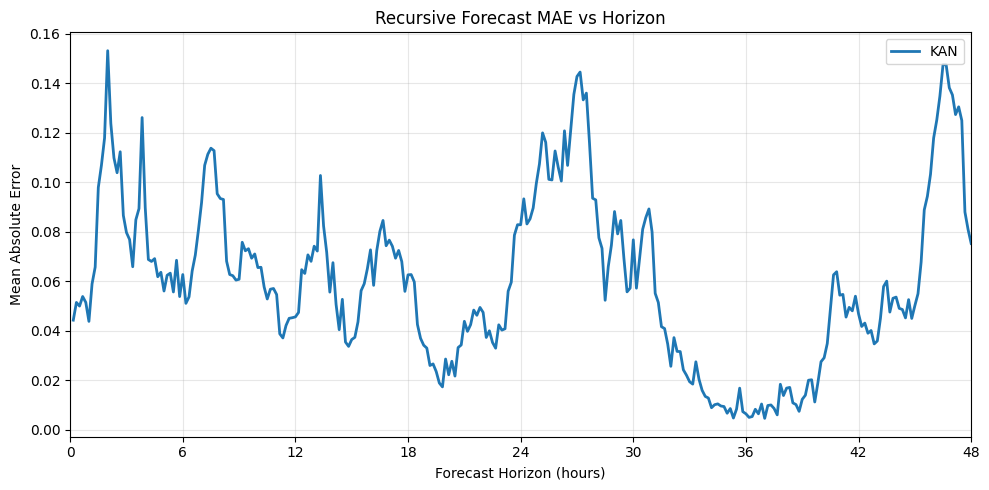

In [25]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))

horizons_in_hours = np.arange(1, len(tables['LSTM']) + 1) / 6

ax.plot(
    horizons_in_hours,
    tables['LSTM']["RMSE"],
    label=name,
    linewidth=2
)

ax.set_xticks(np.arange(0, 49, 6))
ax.set_xlim(0, horizons_in_hours[-1])
ax.set_xlabel("Forecast Horizon (hours)")
ax.set_ylabel("Mean Absolute Error")
ax.set_title("Recursive Forecast MAE vs Horizon")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()
